# 02 · PJM Energy Demand — Advanced EDA II: Temporal Deep-Dive

## Part 2 — Advanced EDA II: The Temporal Deep-Dive

Part 1 mapped the *average* calendar structure. Here we examine the **dynamics** that matter to anyone
operating or forecasting a grid: how fast demand **ramps**, how **volatile** the day is, *when* the
daily peak lands, how the seasonal balance has **shifted over 16 years**, and the **persistence** that
makes load forecastable at all.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

d = data.clean_primary(); s = d.load_mw
print("hours:", len(s))

setup ok | numpy 2.1.3 | pandas 2.3.3


hours: 145392


### 1. Ramp rates — the operator's headache

A grid must *follow* demand minute to minute, so the **hour-to-hour change** (the ramp) is as important
as the level. The mean **morning ramp-up peaks at 07:00 (~+2,450 MW/h)** as the system wakes; the
overnight ramp-down mirrors it. Extreme single-hour ramps reach **±6–7 GW/h** — enough swing to start
or stop a dozen power plants in an hour.

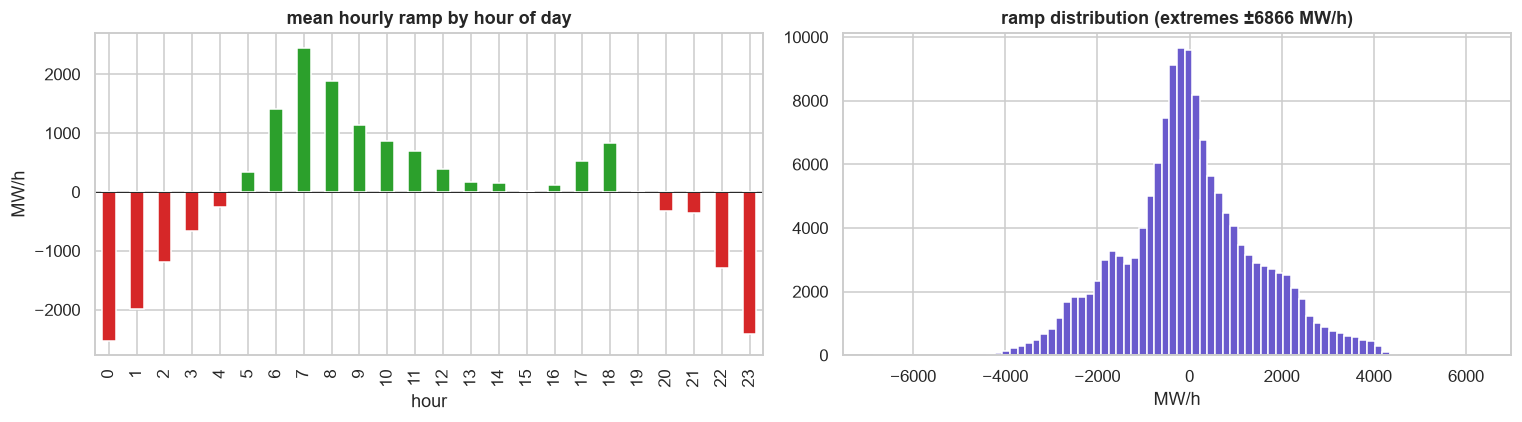

steepest mean up-ramp: hr 7 (+2448) | down-ramp: hr 0 (-2523) | extremes +6326 / -6866


In [2]:
ramp = s.diff()
rh = ramp.groupby(d.hour).mean()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
rh.plot.bar(ax=ax[0], color=["tab:green" if v>0 else "tab:red" for v in rh]); ax[0].set_title("mean hourly ramp by hour of day"); ax[0].set_ylabel("MW/h"); ax[0].axhline(0, color="k", lw=.6)
ax[1].hist(ramp.dropna(), bins=80, color="slateblue"); ax[1].set_title(f"ramp distribution (extremes ±{max(ramp.max(),-ramp.min()):.0f} MW/h)"); ax[1].set_xlabel("MW/h")
fig.tight_layout(); eda.savefig(fig, "p2_ramps.png"); plt.show()
print("steepest mean up-ramp: hr %d (+%.0f) | down-ramp: hr %d (%.0f) | extremes +%.0f / %.0f" %
      (rh.idxmax(), rh.max(), rh.idxmin(), rh.min(), ramp.max(), ramp.min()))

### 2. Intra-day volatility — summer is the hard season

The **daily swing** (that day's max − min) measures how much work the grid does within a day. **Summer
swings ~17 GW vs ~10 GW in winter** — air-conditioning turns hot afternoons into sharp spikes, so even
though winter's *average* demand is high, **summer is the operationally volatile season**.

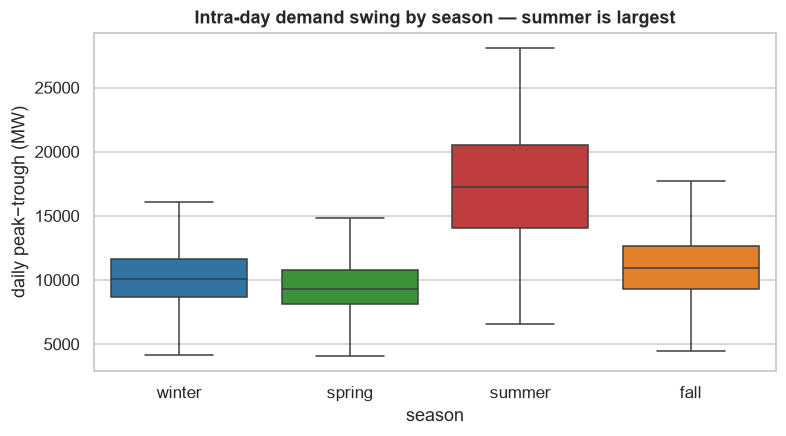

mean daily swing: {'fall': 11399.0, 'spring': 9782.0, 'summer': 17190.0, 'winter': 10139.0}


In [3]:
daily = s.resample("D").agg(["min","max"]); daily["swing"] = daily["max"] - daily["min"]
daily["season"] = pd.Series(daily.index.month % 12 // 3, index=daily.index).map({0:"winter",1:"spring",2:"summer",3:"fall"})
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x="season", y="swing", data=daily.reset_index(), order=["winter","spring","summer","fall"],
            palette=["tab:blue","tab:green","tab:red","tab:orange"], showfliers=False, ax=ax)
ax.set_ylabel("daily peak−trough (MW)"); ax.set_title("Intra-day demand swing by season — summer is largest")
eda.savefig(fig, "p2_swing.png"); plt.show()
print("mean daily swing:", daily.groupby("season").swing.mean().round(0).to_dict())

### 3. When does the daily peak land?

The timing of the daily maximum shifts with season — **summer peaks ~17:00** (afternoon A/C), while
cooler seasons peak in the **evening (19–21:00)** (lighting + cooking after dark). A forecaster that
assumes a fixed peak hour will be wrong half the year.

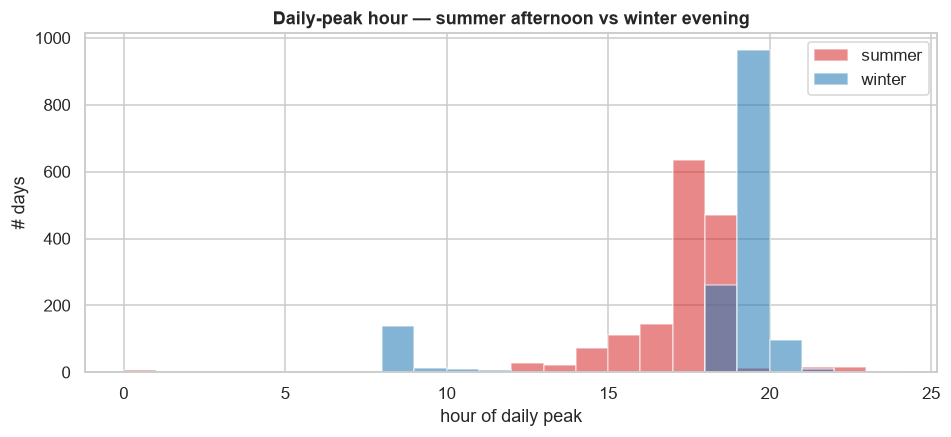

modal peak hour by season: {'fall': 20, 'spring': 21, 'summer': 17, 'winter': 19}


In [4]:
peak_hr = s.groupby(s.index.normalize()).apply(lambda x: x.idxmax().hour)
ph = pd.DataFrame({"hr": peak_hr.values})
ph["season"] = pd.Series(peak_hr.index.month % 12 // 3, index=peak_hr.index).map({0:"winter",1:"spring",2:"summer",3:"fall"}).values
fig, ax = plt.subplots(figsize=(10, 4))
for seas, c in [("summer","tab:red"),("winter","tab:blue")]:
    ax.hist(ph[ph.season==seas].hr, bins=range(0,25), alpha=.55, label=seas, color=c)
ax.set_xlabel("hour of daily peak"); ax.set_ylabel("# days"); ax.set_title("Daily-peak hour — summer afternoon vs winter evening"); ax.legend()
eda.savefig(fig, "p2_peakhour.png"); plt.show()
print("modal peak hour by season:", ph.groupby("season").hr.agg(lambda x: int(x.mode().iloc[0])).to_dict())

### 4. A 16-year shift — toward a summer-peaking system

Tracking each year's **summer vs winter peak** shows the balance tilting: the summer/winter peak ratio
rose from ~1.1 in the mid-2000s toward ~1.3 — consistent with rising air-conditioning saturation and
warming summers. Long histories let you see the *system itself changing*, not just noise.

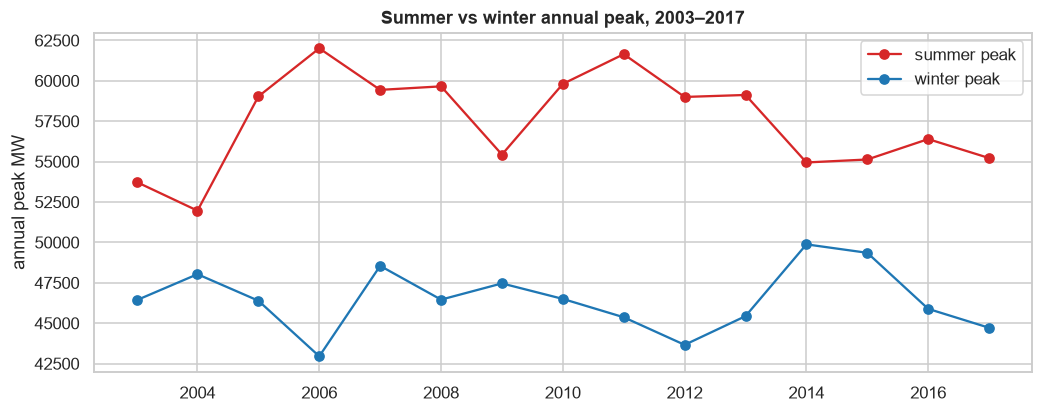

summer/winter peak ratio: 2004 1.08 -> 2012 1.35


In [5]:
yr = s.groupby([d.year, d.season]).max().unstack()
yr = yr.loc[2003:2017]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(yr.index, yr["summer"], "o-", color="tab:red", label="summer peak")
ax.plot(yr.index, yr["winter"], "o-", color="tab:blue", label="winter peak")
ax.set_ylabel("annual peak MW"); ax.set_title("Summer vs winter annual peak, 2003–2017"); ax.legend()
eda.savefig(fig, "p2_peakshift.png"); plt.show()
print("summer/winter peak ratio: 2004 %.2f -> 2012 %.2f" % ((yr.loc[2004,"summer"]/yr.loc[2004,"winter"]), (yr.loc[2012,"summer"]/yr.loc[2012,"winter"])))

### 5. Persistence — why load is so forecastable

Demand is **enormously autocorrelated**: this hour looks like last hour (lag-1 ≈ 0.97), like yesterday
(lag-24 ≈ 0.89) and like last week (lag-168 ≈ 0.78). That persistence is the forecaster's friend —
simple seasonal-naive methods are already strong, and it's why lag features dominate the ML models in
Part 8. Part 3 formalises this with the ACF/PACF and decomposition.

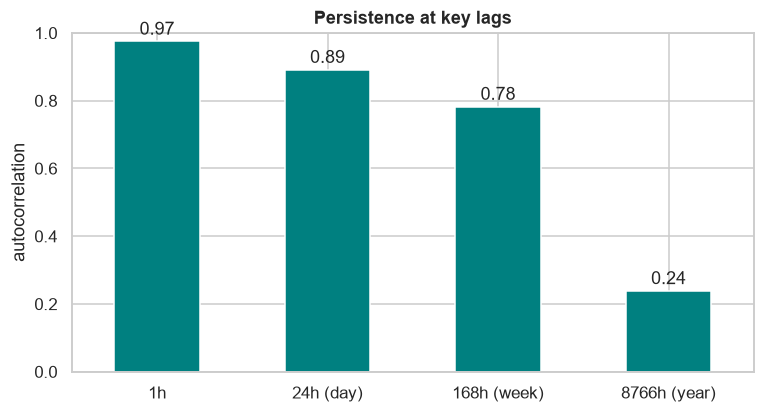

In [6]:
lags = {"1h":1, "24h (day)":24, "168h (week)":168, "8766h (year)":8766}
ac = {k: s.autocorr(v) for k, v in lags.items()}
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(ac).plot.bar(ax=ax, color="teal", rot=0); ax.set_ylabel("autocorrelation"); ax.set_title("Persistence at key lags"); ax.set_ylim(0,1)
for i, v in enumerate(ac.values()): ax.text(i, v+.02, f"{v:.2f}", ha="center")
eda.savefig(fig, "p2_persistence.png"); plt.show()

### Takeaways

- **Ramps** peak at the 07:00 morning wake-up (~+2,450 MW/h mean); extremes hit ±6–7 GW/h — the grid's
  follow-the-load challenge.
- **Summer is the volatile season**: daily swings ~17 GW vs ~10 GW in winter (air-conditioning).
- The **daily peak time shifts** (summer ~17:00, winter ~19–21:00); the **summer/winter peak ratio is
  rising** over 16 years.
- Load is **extremely persistent** (lag-1 0.97, lag-24 0.89, lag-168 0.78) → very forecastable.

**Next — Part 3 (TS foundations):** stationarity tests, the ACF/PACF in full, and **MSTL**
decomposition that separates the trend, the daily/weekly/annual seasonals, and the remainder.